# Time-Frequency Analysis with Morlet Wavelets

In [2]:
import numpy as np
import mne
import matplotlib.pyplot as plt

## Utility Functions

In [3]:
def _plot_wavelets(wavelets, freqs, n_cycles, fs):
    wavelets = wavelets if isinstance(wavelets, list) else [wavelets]
    freqs = np.atleast_1d(freqs)
    n_cycles = np.atleast_1d(n_cycles)
    if len(n_cycles) == 1:
        n_cycles = np.repeat(n_cycles, len(wavelets))
    _, ax = plt.subplots(1, 2, figsize=(10, 4), layout="constrained")
    for wavelet, center_freq, n in zip(wavelets, freqs, n_cycles):
        n_samples = len(wavelet)
        t = np.arange(n_samples) / fs - (n_samples - 1) / (2 * fs)
        ax[0].plot(t, wavelet.real, label=f"{center_freq} Hz, {n} cycles")

        fft_freqs = np.fft.fftfreq(n_samples, 1 / fs)
        spectrum = np.abs(np.fft.fft(wavelet))
        positive = fft_freqs >= 0
        ax[1].plot(fft_freqs[positive], spectrum[positive])
        ax[1].axvline(center_freq, color="gray", linestyle="--", linewidth=1)

    ax[0].set_xlabel("Time [s]")
    ax[0].set_ylabel("Amplitude [a.u.]")
    ax[1].set_xlabel("Frequency [Hz]")
    ax[1].set_ylabel("Magnitude [a.u.]")
    ax[0].legend()

def _simulate_signal(dur, fs, freq, start, stop, noise_level=0.1):
    freqs = np.atleast_1d(freq)
    starts = np.atleast_1d(start)
    stops = np.atleast_1d(stop)
    rng = np.random.RandomState(42)
    data = rng.randn(int(dur * fs)) * noise_level
    t = np.linspace(0, dur, int(dur * fs))
    for freq, s0, s1 in zip(freqs, starts, stops):
        signal = np.sin(np.pi * 2.0 * freq * t)
        signal[np.logical_or(t < s0, t > s1)] = 0.0
        on_time = np.logical_and(t >= s0, t <= s1)
        signal[on_time] *= np.hanning(on_time.sum())
        data += signal
    return t, data

def _simulate_epochs(fs, freq, start, stop, n_epochs, noise_level=0.1, tmin=0, tmax=1):
    dur = tmax - tmin + 1 / fs  # extra sample so tmax fits within the segment
    start_rel = np.atleast_1d(start) - tmin  # convert to segment-relative time
    stop_rel = np.atleast_1d(stop) - tmin
    segments = [_simulate_signal(dur, fs, freq, start_rel, stop_rel, noise_level)[1] for _ in range(n_epochs)]
    all_data = np.concatenate(segments)[np.newaxis, :]
    info = mne.create_info(ch_names=["CH1"], sfreq=fs, ch_types="eeg")
    raw = mne.io.RawArray(all_data, info)
    events = np.zeros((n_epochs, 3), dtype=int)
    event_offset = int(max(0, -tmin) * fs)
    events[:, 0] = np.arange(n_epochs) * int(dur * fs) + event_offset
    epochs = mne.Epochs(raw, events, tmin=tmin, tmax=tmax, baseline=None)
    return epochs


class utils:
    plot_wavelets = _plot_wavelets
    simulate_signal = _simulate_signal
    simulate_epochs = _simulate_epochs

EEG and MEG signals are non-stationary: their frequency content changes over time. To capture these dynamics, we need methods that provide both time and frequency information simultaneously. In this session we will use **Morlet wavelets** — short, frequency-specific filters — to decompose signals into their time-varying frequency components. We will start by constructing wavelets and understanding their parameters, then work with simulated data to apply them via convolution to extract instantaneous power at a given frequency, and finally use MNE's `compute_tfr` to compute full time-frequency representations (TFRs) of epoched data. Once you understood how to compute and interpret the TFR, you'll apply that knowledge to a real EEG dataset to investigate recordings from a motor-imagery task that is common in the brain-computer interface literature.

### Background

To analyze the time-varying frequency content, we need filters that isolate specific frequency bands with high spectral and temporal precision. One commonly used type of filters are Morlet wavelets which are obtained by multiplying a (complex) sinusoid with a Gaussian envelope. A Morlet wavelet has two key parameters: its **frequency** and the **number of cycles** within the Gaussian envelope.

Together, these control the time-frequency tradeoff: more cycles produce a longer wavelet with narrower bandwidth (better frequency resolution, worse temporal resolution), while fewer cycles produce a shorter wavelet with broader bandwidth (better temporal resolution, worse frequency resolution). When keeping the number of cycles constant while increasing the wavelet's frequency, the wavelet will get shorter (because each cycle takes less time) and the frequency resolution decreases. This can be compensated by proportionally increasing the number of cycles with the wavelet's frequency.

Like any signal, wavelets are subject to the Nyquist theorem which says that the highest representable frequency is half of the sampling rate. In practice however, it is recommended to stay below one third or fourth of the sampling rate to avoid aliasing artifacts.

### Exercises

In this section, you are going to use MNE's `morlet()` function to generate wavelets of varying frequency and cycle number. By using the custom function `utils.plot_wavelets()` you'll be able to see the tradeoffs that are part of any time-frequency analysis.

| Code | Description |
|---|---|
| `mne.time_frequency.morlet(sfreq=fs, freqs=10, n_cycles=7)` | Create a Morlet wavelet at 10 Hz with 7 cycles |
| `mne.time_frequency.morlet(sfreq=fs, freqs=[5, 10, 20], n_cycles=7)` | Create wavelets at multiple frequencies with a fixed number of cycles |
| `mne.time_frequency.morlet(sfreq=fs, freqs=freqs, n_cycles=freqs/2)` | Scale `n_cycles` proportionally to frequency to keep bandwidth constant |
| `utils.plot_wavelets(wavelet, freqs, n_cycles, fs)` | Plot wavelet(s) in the time domain (left) and frequency domain (right) |

**Example**: Create a Morlet wavelet with 3 cycles and a frequency of 5 Hz at a sampling rate of 125 Hz. Plot it using `utils.plot_wavelets` — the left panel shows the wavelet in the time domain and the right panel shows its magnitude spectrum.

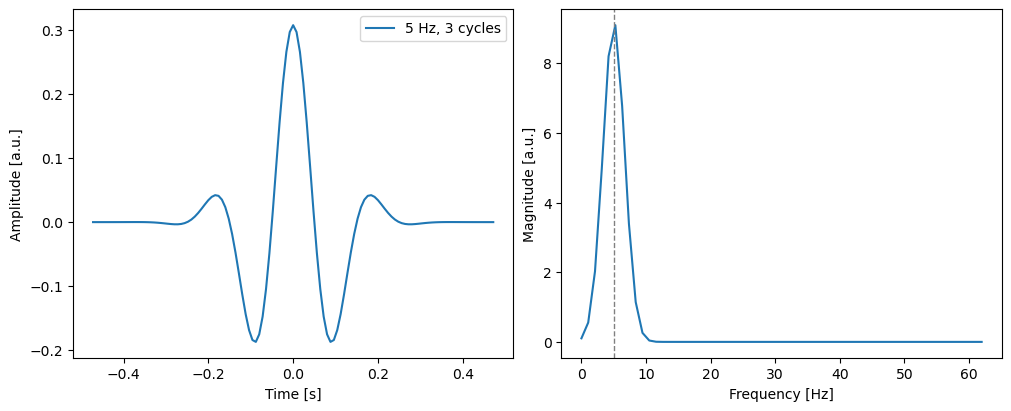

In [4]:
fs = 125
freq = 5
n_cycles = 3

wavelet = mne.time_frequency.morlet(sfreq=fs, freqs=freq, n_cycles=n_cycles)
utils.plot_wavelets(wavelet, freq, n_cycles, fs)


**Exercise**: Create the same wavelet but increase the number of cycles to 6. How did increasing the number of cycles affect the length of the wavelet and its magnitude spectrum?

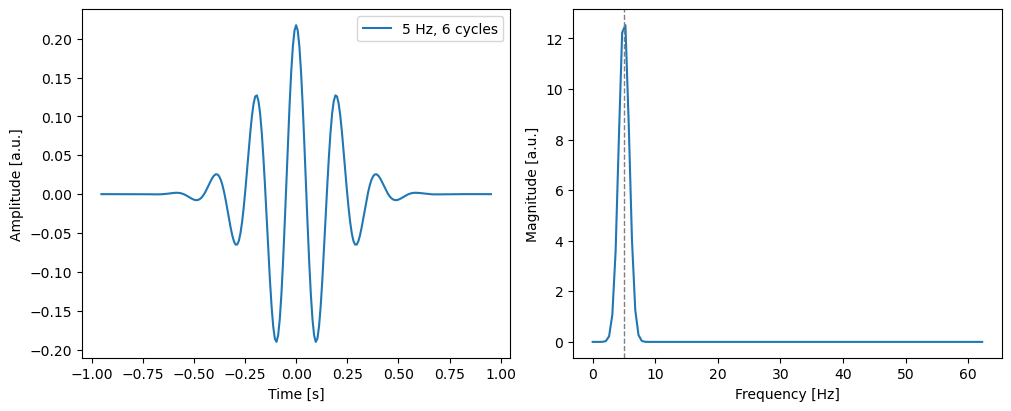

In [5]:
fs = 125
freq = 5
n_cycles = 6

wavelet = mne.time_frequency.morlet(sfreq=fs, freqs=freq, n_cycles=n_cycles)
utils.plot_wavelets(wavelet, freq, n_cycles, fs)

**Exercise**: Create the same wavelet but increase the frequency to 15 Hz. How did increasing the frequency affect the length of the wavelet and its magnitude spectrum?

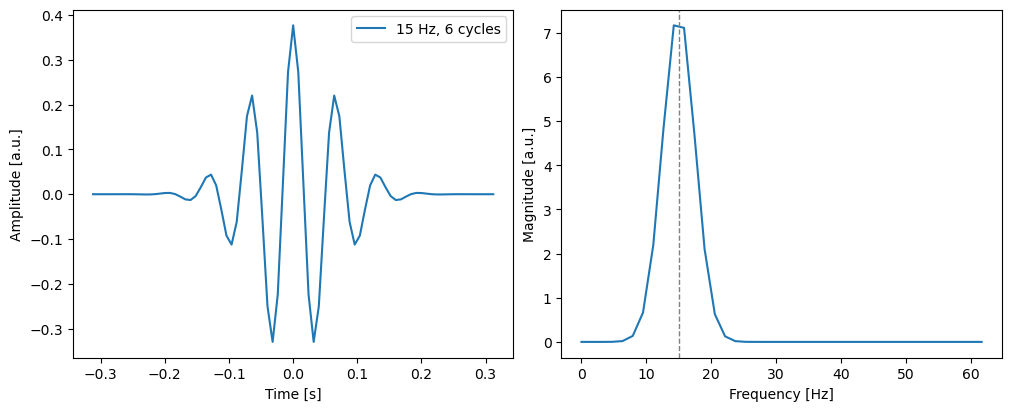

In [6]:
fs = 125
freq = 15
n_cycles = 6

wavelet = mne.time_frequency.morlet(sfreq=fs, freqs=freq, n_cycles=n_cycles)
utils.plot_wavelets(wavelet, freq, n_cycles, fs)


**Example**: Generate wavelets for an array of frequencies and plot them. With a constant number of cycles, the spectral bandwidth increases with frequency as the wavelet gets shorter.

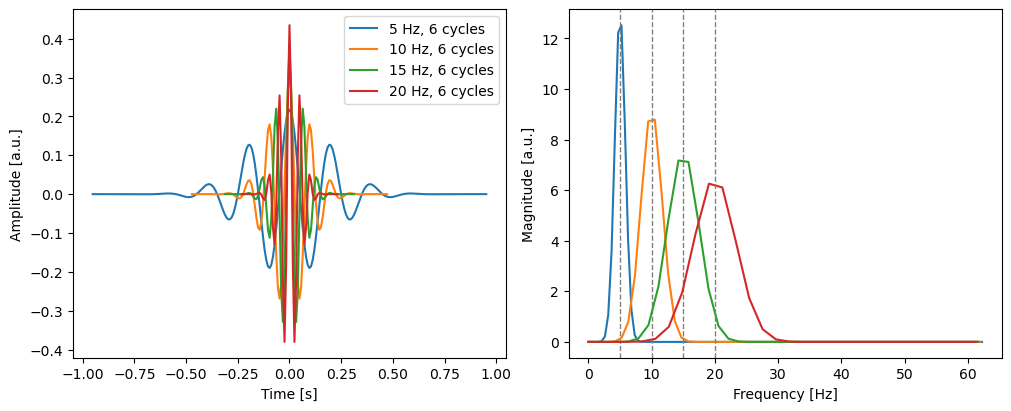

In [7]:
fs = 125
freqs = np.array([5, 10, 15, 20])
n_cycles = 6

wavelet = mne.time_frequency.morlet(sfreq=fs, freqs=freqs, n_cycles=n_cycles)
utils.plot_wavelets(wavelet, freqs, n_cycles, fs)

**Exercise**: Generate wavelets for the same `freqs` but set the number of cycles to `freqs/2` to scale the number of cycles with the frequency. How does this affect the spectral resolution?

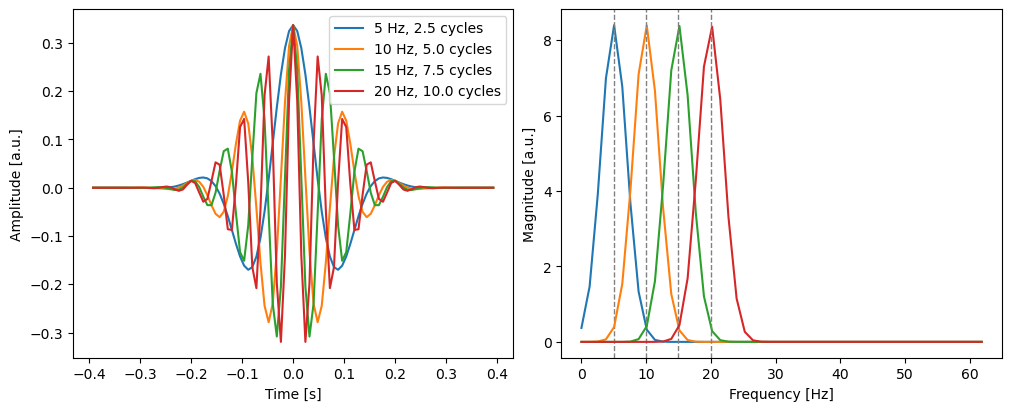

In [8]:
fs = 125
freq = np.array([5, 10, 15, 20])
n_cycles = freq/2

wavelet = mne.time_frequency.morlet(sfreq=fs, freqs=freq, n_cycles=n_cycles)
utils.plot_wavelets(wavelet, freq, n_cycles, fs)

**Example**: Plot wavelets for 40, 60 and 80 Hz at a sampling rate of 125 Hz. Notice how the wavelets are increasingly distorted as they approach and cross the Nyquist frequency which is half of the sampling rate.

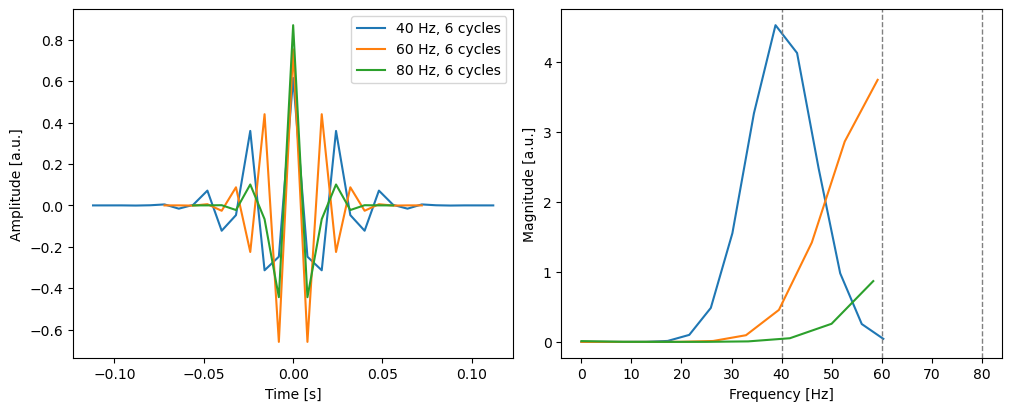

In [9]:
fs = 125
freq = np.array([40, 60, 80])
n_cycles = 6

wavelet = mne.time_frequency.morlet(sfreq=fs, freqs=freq, n_cycles=n_cycles)
utils.plot_wavelets(wavelet, freq, n_cycles, fs)

**Exercise**: Create the same wavelets again but increase the sampling rate to 500 Hz.

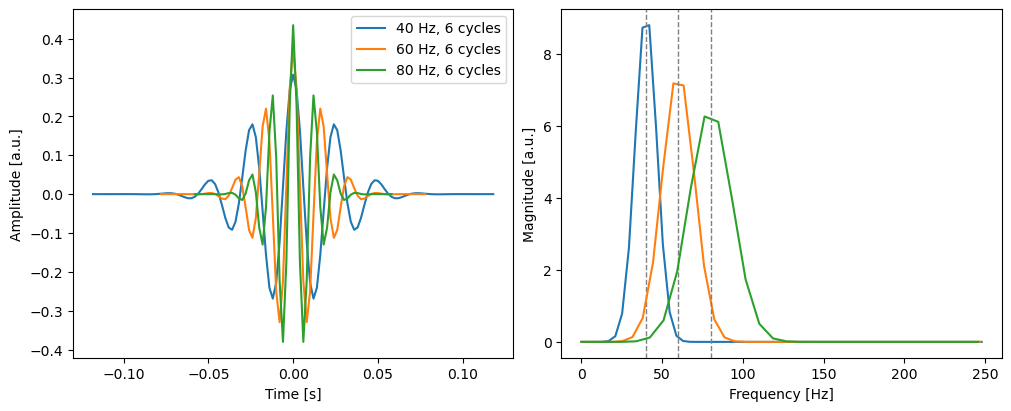

In [10]:
fs = 500
freq = np.array([40, 60, 80])
n_cycles = 6

wavelet = mne.time_frequency.morlet(sfreq=fs, freqs=freq, n_cycles=n_cycles)
utils.plot_wavelets(wavelet, freq, n_cycles, fs)

### Background

Wavelets are applied to a signal via convolution. This acts as a narrow bandpass filter at the wavelet's frequency. Because the wavelet is complex (i.e. it has a real and an imaginary component), the convolution result is also complex: its real part is the bandpass-filtered signal, and its magnitude is the instantaneous amplitude envelope at that frequency. Squaring the magnitude gives the instantaneous power.

By repeating this operation at many different center frequencies, we obtain the time-varying power at each frequency — the foundation of the full wavelet time-frequency decomposition.

### Exercises

In this section you are going to apply the wavelets you generated in the previous section to a simulated signal and compute the power of the filtered signal. Here are the essential code snippets:

| Code | Description |
|---|---|
| `np.convolve(signal, wavelet, mode="same")` | Apply the wavelet as a bandpass filter by convolution |
| `filtered.real` | Real part of the filtered signal (the bandpass-filtered waveform) |
| `np.abs(filtered) ** 2` | Instantaneous power at the wavelet's center frequency |

Simulate a signal with a transient 10 Hz oscillation.

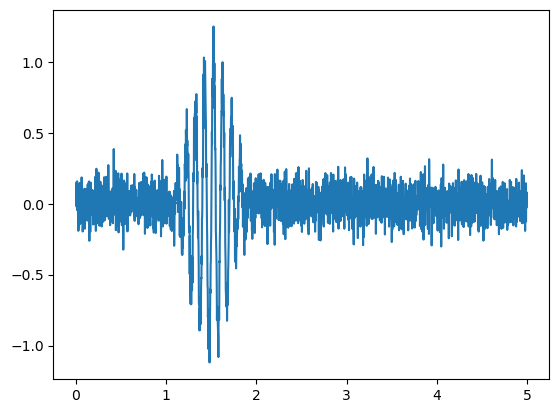

In [11]:
t, signal = utils.simulate_signal(dur=5, fs=500, freq=10, start=1, stop=2)
plt.plot(t, signal)

**Example**: Create a 5 Hz wavelet with 3 cycles and convolve it with the `signal` and plot the signal together with the `.real` part of the filtered result.

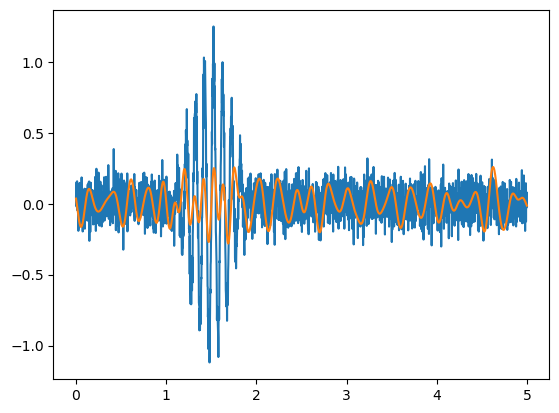

In [12]:
wavelet = mne.time_frequency.morlet(sfreq=fs, freqs=5, n_cycles=3)
filtered = np.convolve(signal, wavelet, mode="same")

plt.plot(t, signal)
plt.plot(t, filtered.real)

**Exercise**: Create a 10 Hz wavelet with 3 cycles and convolve it with the `signal` and plot the signal together with the `.real` part of the filtered result. How does the `filtered` signal differ from the previous example?

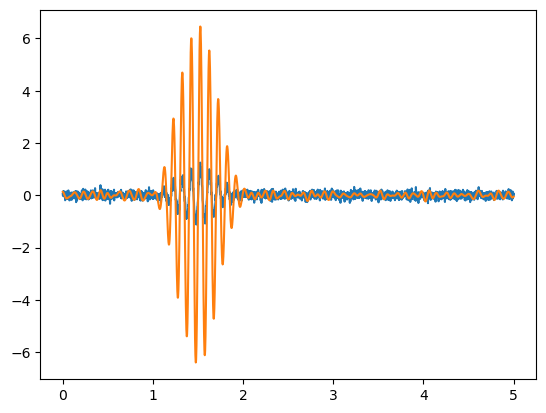

In [13]:
wavelet = mne.time_frequency.morlet(sfreq=fs, freqs=10, n_cycles=3)
filtered = np.convolve(signal, wavelet, mode="same")

plt.plot(t, signal)
plt.plot(t, filtered.real)

**Exercise**: Create a 15 Hz wavelet with 3 cycles and convolve it with the `signal`. Plot the signal together with the `.real` part of the filtered result. How does it differ from the 10 Hz example?

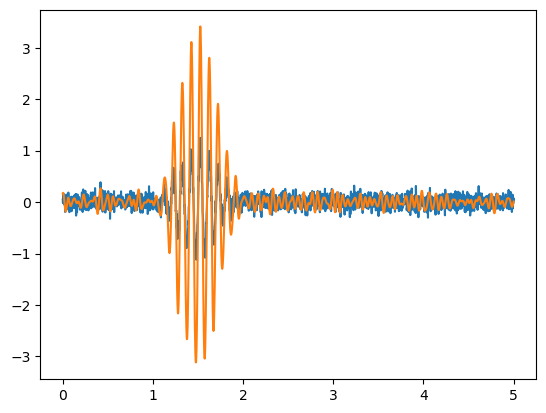

In [14]:
wavelet = mne.time_frequency.morlet(sfreq=fs, freqs=15, n_cycles=3)
filtered = np.convolve(signal, wavelet, mode="same")

plt.plot(t, signal)
plt.plot(t, filtered.real)

**Exercise**: Repeat the previous exercise but increase the number of cycles to 10. How does that affect the amplitude of the `filtered` signal?

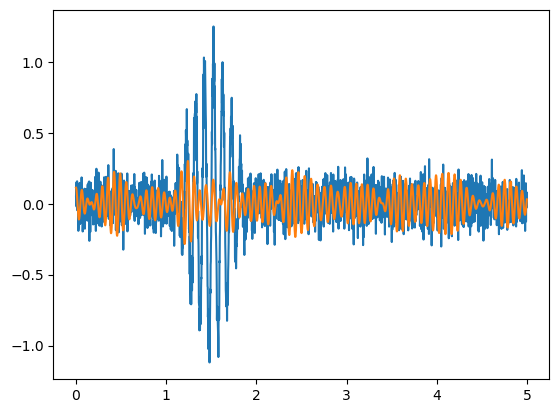

In [15]:
wavelet = mne.time_frequency.morlet(sfreq=fs, freqs=15, n_cycles=10)
filtered = np.convolve(signal, wavelet, mode="same")

plt.plot(t, signal)
plt.plot(t, filtered.real)

**Example**: Convolve the signal with a 5 Hz wavelet with 3 cycles and compute the instantaneous power by squaring the magnitude of the `filtered` result. Plot the original signal, the real part of `filtered`, and the `power`.

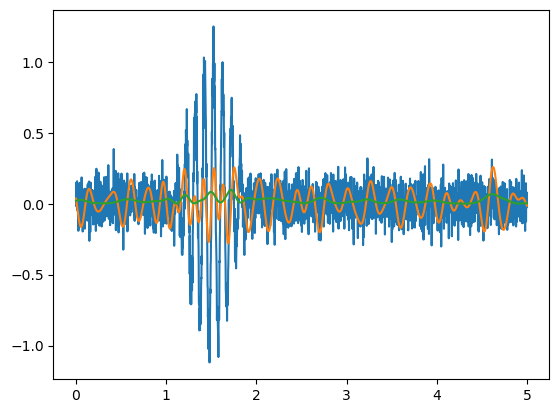

In [16]:
wavelet = mne.time_frequency.morlet(sfreq=fs, freqs=5, n_cycles=3)
filtered = np.convolve(signal, wavelet, mode="same")
power = np.abs(filtered) ** 2

plt.plot(t, signal)
plt.plot(t, filtered.real)
plt.plot(t, power)


**Exercise**: Convolve the signal with a 10 Hz wavelet with 3 cycles and compute the instantaneous power by squaring the magnitude of the `filtered` result. Plot the original signal, the real part of `filtered`, and the `power`. How does the power differ from the 5 Hz example?

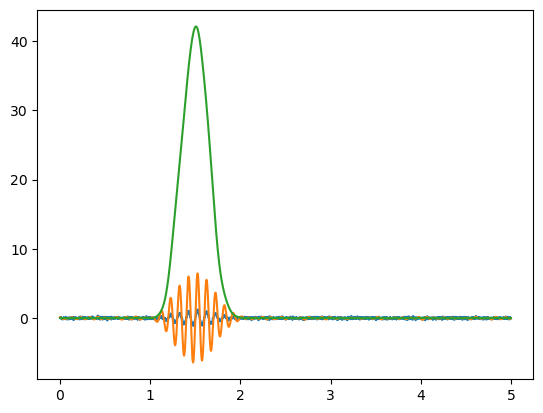

In [17]:
wavelet = mne.time_frequency.morlet(sfreq=fs, freqs=10, n_cycles=3)
filtered = np.convolve(signal, wavelet, mode="same")
power = np.abs(filtered) ** 2

plt.plot(t, signal)
plt.plot(t, filtered.real)
plt.plot(t, power)


## Time-Frequency Representation of Epochs

### Background

In the previous section, we convolved individual signals with wavelets one frequency at a time. MNE's `.compute_tfr` method automates this across multiple frequencies, channels and epochs. The result is an `EpochsTFR` object that contains a two-dimensional time × frequency power matrix for each epoch. Averaging across epochs reveals consistent oscillatory dynamics while noise averages out — like an ERP, but frequency-specific.

When visualizing the average power, a (typically pre-stimulus) interval is used as a baseline and subtracted for every frequency bin. This is necessary because the frequency spectrum of EEG and MEG recordings follows a 1/f distribution where power decreases with frequency. Without baseline correction, the low-frequency components would dominate the plot and higher frequencies would be invisible.

An additional concern is edge artifacts: at the start and end of each epoch, the wavelet extends beyond the available data, causing spurious increases in power. These can be removed by cropping the time-frequency representation — the recommended amount to crop from each edge is half the duration of the longest wavelet (i.e., `n_cycles / (2 * fmin)`).

### Exercises

In this section, you are going to use `.compute_tfr()` on simulated epochs to compute and visualize their time-frequency representation. By changing the number of `freqs` you can control the visual resolution of the time-frequency plot but not the actual resolution, which is controlled by `n_cycles`. Here are some code examples:

| Code | Description |
|---|---|
| `epochs.compute_tfr(method="morlet", freqs=freqs, n_cycles=7)` | Compute TFR for all epochs using Morlet wavelets |
| `epochs.compute_tfr(method="morlet", freqs=freqs, n_cycles=freqs/2)` | Scale `n_cycles` with frequency for a constant time-frequency tradeoff |
| `power.crop(tmin, tmax)` | Remove edge-artifact-contaminated time points from the TFR |
| `power.apply_baseline((tmin, tmax))` | Subtract the mean power in the baseline interval, per frequency |
| `power.average().plot()` | Average TFR across epochs and plot |

First, we simulate 40 epochs of a 500 Hz signal with three transient oscillations at 10 Hz, 20 Hz and 40 Hz that appear at different times.

Creating RawArray with float64 data, n_channels=1, n_times=20040
    Range : 0 ... 20039 =      0.000 ...    40.078 secs
Ready.
Not setting metadata
40 matching events found
No baseline correction applied
0 projection items activated
Need more than one channel to make topography for eeg. Disabling interactivity.


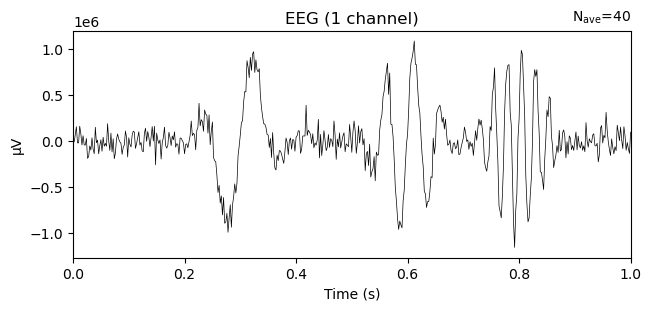

In [22]:
epochs = utils.simulate_epochs(
    tmin=0,
    tmax=1,
    fs=500,
    freq=[10, 20, 40], # oscillation frequencies
    start=[0.2, 0.5, 0.7], # oscillation starts
    stop=[0.4, 0.7, 0.9], # oscillation stops
    n_epochs=40,
    noise_level=0.1)
epochs.average().plot();

**Example**: Compute the time-frequency representation of `epochs` for frequencies from 5 to 55 Hz in steps of 5 Hz using 2 cycles per wavelet. Average the result across epochs and plot it.

Using data from preloaded Raw for 40 events and 501 original time points ...
0 bad epochs dropped
No baseline correction applied


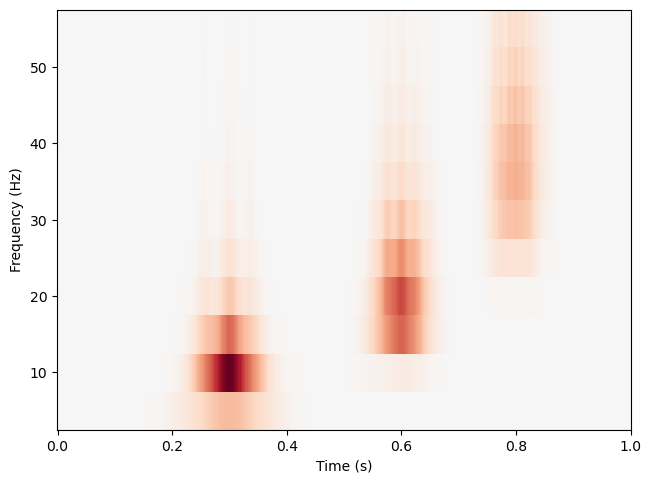

In [23]:
freqs = np.arange(5, 60, 5)
power = epochs.compute_tfr(method="morlet", freqs=freqs, n_cycles=2)
power.average().plot(colorbar=False);

**Exercise**: Repeat the example above but increase `n_cycles` to 3. How does this affect the time and frequency resolution of the TFR?

Using data from preloaded Raw for 40 events and 501 original time points ...
No baseline correction applied


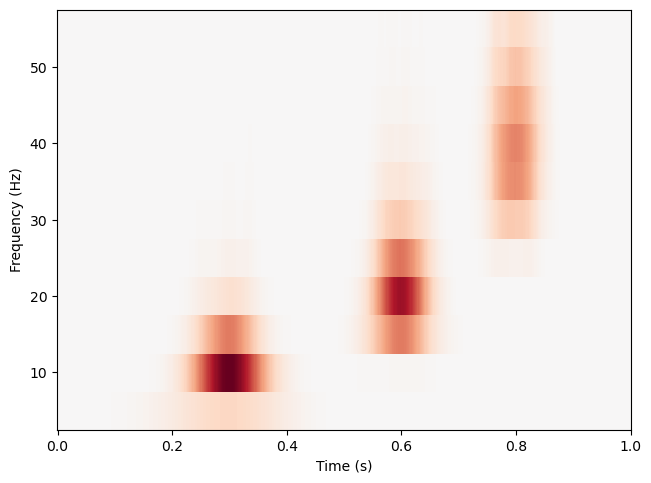

In [24]:
freqs = np.arange(5, 60, 5)
power = epochs.compute_tfr(method="morlet", freqs=freqs, n_cycles=3)
power.average().plot(colorbar=False);

**Exercise**: Reduce the step size in the array of `freqs` to 1 to increase the resolution of the time-frequency representation and plot the power again.

Using data from preloaded Raw for 40 events and 501 original time points ...
No baseline correction applied


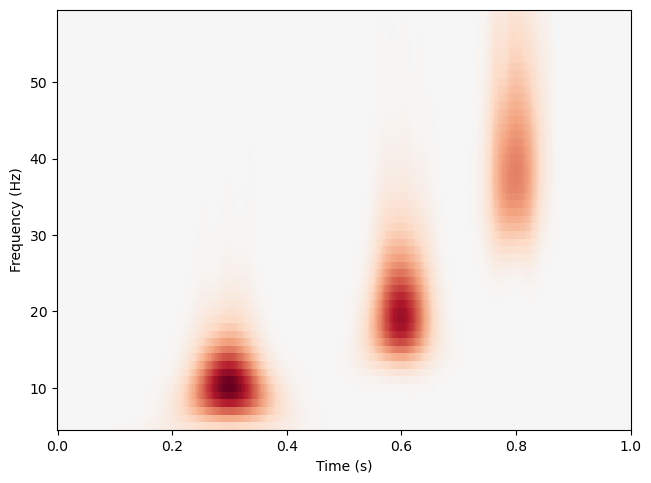

In [25]:
freqs = np.arange(5, 60, 1)
power = epochs.compute_tfr(method="morlet", freqs=freqs, n_cycles=3)
power.average().plot(colorbar=False);

**Exercise**: Repeat the code from above but set `n_cycles` to `freqs/2` to scale the number of cycles with the wavelet's frequency.

Using data from preloaded Raw for 40 events and 501 original time points ...
No baseline correction applied


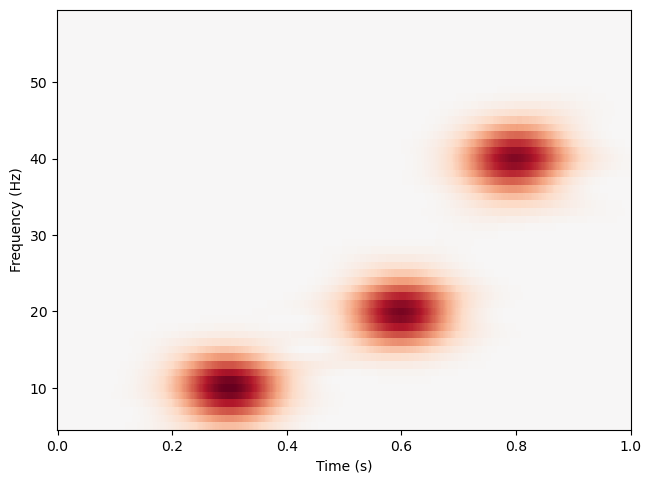

In [26]:
freqs = np.arange(5, 60.0, 1.0)
power = epochs.compute_tfr(method="morlet", freqs=freqs, n_cycles=freqs/2)
power.average().plot(colorbar=False);

The simulated data we used so far was unrealistically clean for EEG. Let's regenerate the epochs with a 10 times larger noise level so that the oscillations are completely buried.

Creating RawArray with float64 data, n_channels=1, n_times=60040
    Range : 0 ... 60039 =      0.000 ...   120.078 secs
Ready.
Not setting metadata
40 matching events found
No baseline correction applied
0 projection items activated
Need more than one channel to make topography for eeg. Disabling interactivity.


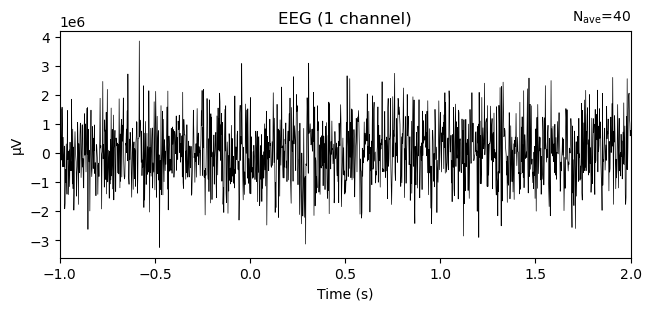

In [27]:
epochs = utils.simulate_epochs(
    tmin=-1,
    tmax=2,
    fs=500,
    freq=[10, 20, 40], # oscillation frequencies
    start=[0.2, 0.5, 0.7], # oscillation starts
    stop=[0.4, 0.7, 0.9], # oscillation stops
    n_epochs=40,
    noise_level=1)
epochs.average().plot();

The cell below computes and plots the time-frequency representation with `n_cycles=6` for every wavelet. There are two important differences compared to the previous plot:
1. There are edge artifacts along the left and right borders of the plot
2. It is much harder to distinguish genuine oscillations from random noise

To address these problems we can:
1. Crop the edges of the TFR that are affected by artifacts
2. Apply a baseline correction to normalize power relative to a pre-stimulus period

Using data from preloaded Raw for 40 events and 1501 original time points ...
0 bad epochs dropped
No baseline correction applied


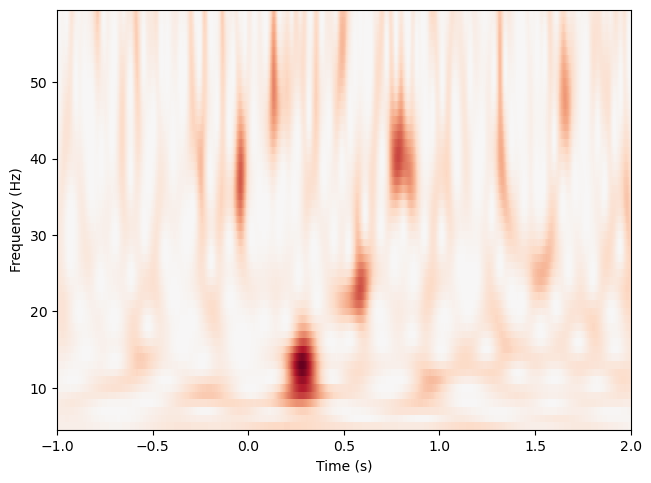

In [28]:
freqs = np.arange(5, 60.0, 1.0)
n_cycles = 6
power = epochs.compute_tfr(method="morlet", freqs=freqs, n_cycles=n_cycles)
power.average().plot(colorbar=False);

**Exercise**: Use the `.crop()` method to crop `t_crop` from the start and end of `power` and re-create the time-frequency plot. The typical recommendation is to crop half of the length of the longest wavelet (i.e. the one with the lowest frequency).

In [29]:
t_crop = n_cycles / (freqs.min()*2)
t_crop

np.float64(0.6)

No baseline correction applied


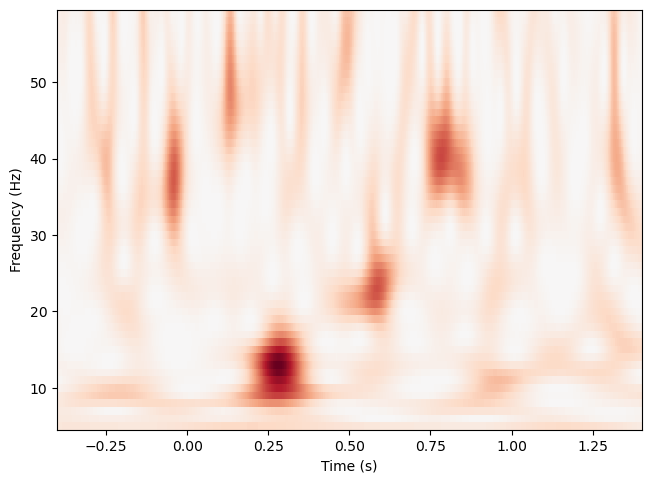

In [30]:
power.crop(-0.4, 1.4)
power.average().plot(colorbar=False);

**Exercise**: Use the `.apply_baseline()` method to apply a baseline correction using the time interval before 0 and re-create the time-frequency plot.

Applying baseline correction (mode: mean)
No baseline correction applied


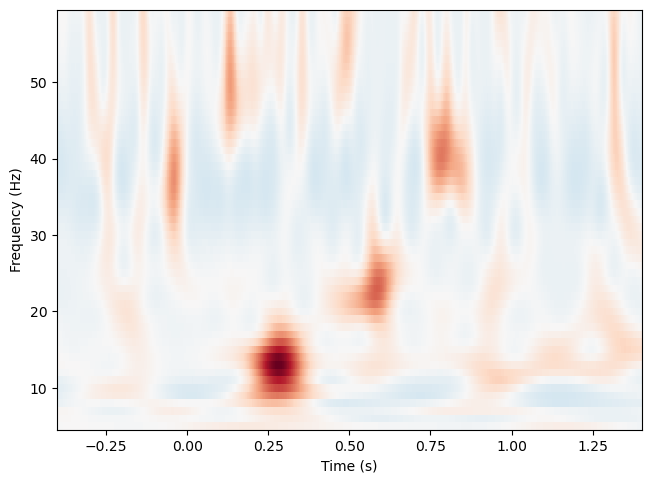

In [31]:
power.apply_baseline((None, 0))
power.average().plot(colorbar=False);

## Bonus: Applying Time-Frequency Analysis to Real EEG Data

### Background

Now that you know how to compute and interpret time-frequency plots, it's time to apply the analysis to real EEG data. In this section we will use wavelet decomposition to analyze the [EEGBCI dataset](https://mne.tools/stable/generated/mne.datasets.eegbci.load_data.html) where subjects were asked to imagine moving the left or right hand following a visual cue. Such motor imagery is known to induce event-related desynchronization (ERD) because motor neurons transition from an "idle" synchronized alpha rhythm to high-frequency asynchronous firing which does not sum to visible scalp potentials. Because the ERD is not phase-locked to the stimulus, it is invisible in the ERP — but a time-frequency representation can reveal it (see [Pfurtscheller & Lopes da Silva, 1999](https://www.sciencedirect.com/science/article/pii/S1388245799001418)).

The ERD appears as a sustained drop in power in the alpha band (8–13 Hz) and should be largest at the electrodes C3 and C4, which approximately overlie the left and right primary motor cortex. Because of the contralateral organization of the motor system, the ERD should be largest over the right hemisphere for left-hand motor imagery and vice versa. This asymmetry can be used by brain-computer interfaces (BCI) to decode the intended movement of the participant.

### Exercises

In this section you will apply what you have learned using simulated data to real EEG recordings. The only new command is `.plot_topomap()`, which plots the average power across a given time and frequency window as a scalp topography.

| Code | Description |
|---|---|
| `epochs.compute_tfr(method="morlet", freqs=freqs, n_cycles=n_cycles)` | Compute TFR for all epochs |
| `power.crop(tmin, tmax)` | Remove edge-artifact-contaminated time points |
| `power.apply_baseline((tmin, tmax))` | Apply baseline correction per frequency |
| `power["condition"].average().plot(picks=["channel"])` | Plot TFR for a specific condition and channel |
| `power["condition"].average().plot_topomap(tmin=t0, tmax=t1, fmin=f0, fmax=f1)` | Plot scalp topography averaged over a time and frequency window |

First, we load and epoch the data. Every epoch starts with a visual cue that prompts the participant to imagine moving the `"left"` or `"right"` hand. The epochs go from `tmin=-1` to `tmax=3` seconds which gives us a buffer for cropping the edge artifacts from the wavelet transformation.

In [32]:
raw_fnames = mne.datasets.eegbci.load_data(subjects=1, runs=[4, 8, 12])  # motor imagery runs
event_id = {"left": 1, "right": 2}
epochs = []
for fname in raw_fnames:
    raw = mne.io.read_raw_edf(fname, preload=True, verbose=False)
    events = mne.events_from_annotations(raw, verbose=False)[0]
    raw.filter(1, 40, verbose=False)
    epochs.append(
        mne.Epochs(raw, events, event_id, tmin=-1, tmax=3, baseline=None, verbose=False)
    )
epochs = mne.concatenate_epochs(epochs, verbose=False)
montage = mne.channels.make_standard_montage("standard_1005")
epochs.rename_channels(lambda name: name.strip('.'))
epochs.set_montage(montage, match_case=False);

Download complete in 42s (7.4 MB)


C:\Users\olebi\AppData\Local\Temp\ipykernel_35712\3637866404.py:11: RuntimeWarning: Concatenation of Annotations within Epochs is not supported yet. All annotations will be dropped.
  epochs = mne.concatenate_epochs(epochs, verbose=False)


The ERP shows little stimulus-locked activity, which is expected — motor imagery does not produce a strong phase-locked response.

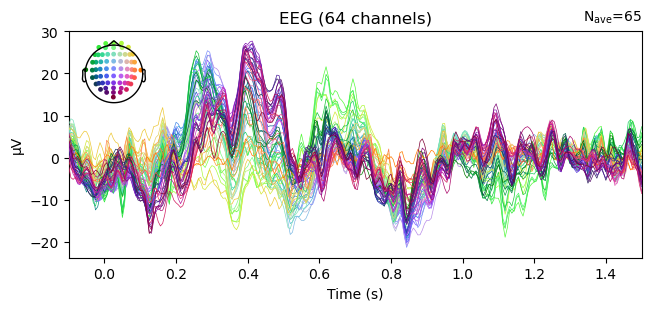

In [33]:
epochs.average().crop(-0.1, 1.5).plot();

**Exercise**: Combine what you learned so far:
- Create an array of `freqs` covering the alpha and beta bands (8–30 Hz)
- Compute the time-frequency representation using an appropriate number of `n_cycles`
- Crop the edges of the TFR to remove artifacts
- Apply a baseline correction
- Plot the result using the average power across all channels (`combine="mean"`)

Applying baseline correction (mode: mean)
No baseline correction applied


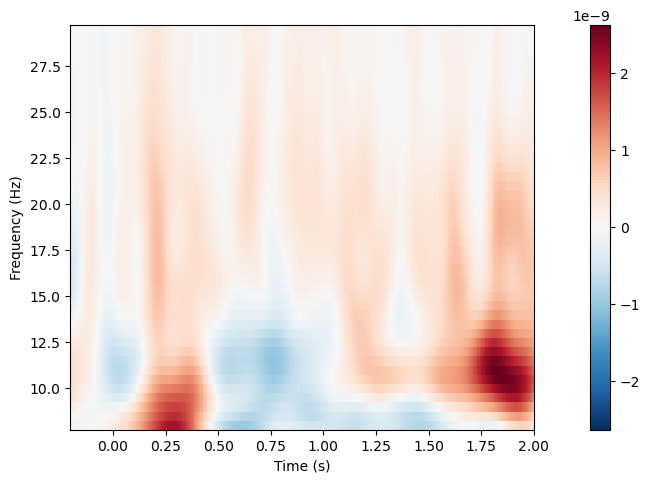

In [34]:
freqs = np.arange(8, 30, 0.5)
power = epochs.compute_tfr( method="morlet", freqs=freqs, n_cycles=6)
power.crop(-0.2, 2)
power.apply_baseline((-0.2, 0))
power.average().plot(combine="mean");

**Exercise**: Once you have found the right parameters, plot the TFR for the `"left"` condition at the right central channel `"C4"` and the TFR for the `"right"` condition at the left central channel `"C3"` (Hint: `power["condition"].average().plot(picks=["channel"])`). Do you see the ERD contralateral to the imagined movement?

No baseline correction applied


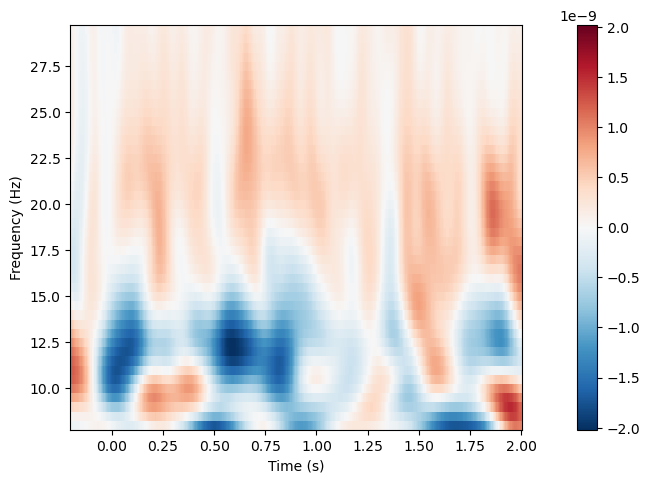

No baseline correction applied


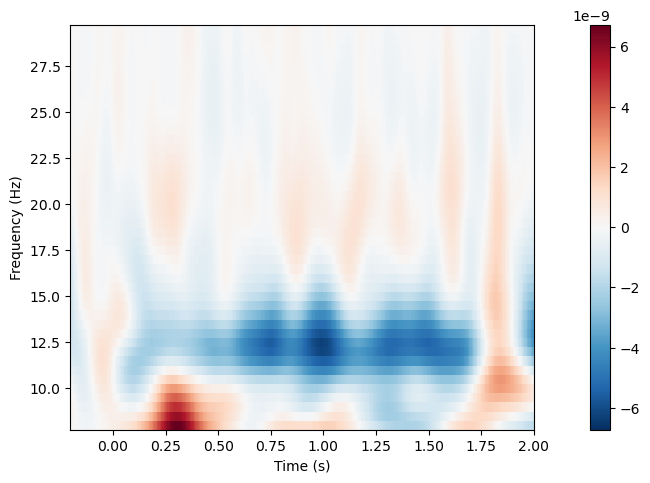

In [35]:
power["left"].average().plot(picks=["C4"])
power["right"].average().plot(picks=["C3"]);

**Exercise**: Plot the average scalp topography over a time windows that shows the ERD in the alpha band (10–13 Hz) for the `"right"` and `"left"` hand condition separately. Can you spot the hemispheric asymmetry?

No baseline correction applied


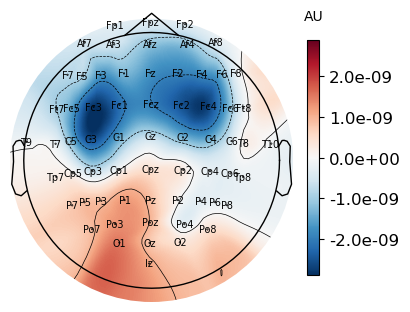

No baseline correction applied


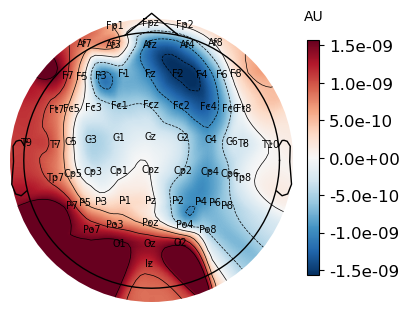

In [36]:
power["right"].average().plot_topomap(tmin=0.25, tmax=1, fmin=10, fmax=13, size=4, show_names=True);
power["left"].average().plot_topomap(tmin=0.25, tmax=1, fmin=10, fmax=13, size=4, show_names=True);